# App-Store Rankings — a quantitative teardown 🔬
### Cross-sectional Spearman IC · IC *t*-stat · label-shuffle placebo · long-short (gross & net) · four-window sign wander · seed-robust positive control · signal-noise sweep

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We treat app-ranking improvement as a cross-sectional alpha signal and run the standard alt-data toolkit: the **information coefficient** (Spearman rank correlation of signal vs forward return) and its *t*-stat, a long-short tercile spread, a placebo null, and a seed-robust control.

> ⚠️ **Synthetic-only, by data necessity.** No free, point-in-time, survivorship-clean App Store ranking panel exists (Apple has no historical rank API; vendor history is licensed and modelled). `fetch_panel(fetch=True)` *raises* rather than fabricate a tape. So `HAVE_REAL` is always False, the honest headline is the seeded **null world**, and the study is capped at `WEAK` (a `REAL` stamp needs a robust *t* >= 2 on a real tape). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from app_store_rankings import data, strategy as st

# There is NO free App Store ranking tape (Apple has no historical rank API; vendor history is
# licensed/modelled). fetch_panel(fetch=False) returns empty -> HAVE_REAL is always False, and this
# study is synthetic-only. The honest headline is the seeded NULL world; the planted world is the
# positive control (never a real-tape banner).
HAVE_REAL = not data.fetch_panel(fetch=False).empty   # always False by construction
NULL = data.synthetic_history(rank_alpha=0.0, seed=552)       # honest headline (no signal)
PLANT = data.synthetic_history(rank_alpha=0.15, seed=552)     # positive control (signal planted)
print("real App-Store ranking tape present:", HAVE_REAL, "(synthetic-only study)")
print(f"null history fp {data.fingerprint(NULL)} | planted fp {data.fingerprint(PLANT)}"
      f" | {NULL['month'].nunique()} months x {NULL['ticker'].nunique()} names")


real App-Store ranking tape present: False (synthetic-only study)
null history fp fc780c9f143d | planted fp 5b92f4d9fdb5 | 48 months x 30 names


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | No real tape exists → no robust *t* >= 2 on real data. Honest (null) world: mean IC **+0.01** (*t* **+0.39**), placebo *p* 0.7. Engine is faithful (planted 0.15 → IC-*t* **+3.00**; null → **+0.12**) but the effect sinks under realistic noise. |
| **Tradability** | `MIRAGE` | Monthly long-short, short leg = hard-to-borrow sinking-app tail. Null world gross **-0.53%/mo** → net **-1.02%/mo** (10 bps/leg × 4 + 100 bps/yr borrow). |

> 💡 In plain words: the detector works, but the honest run is flat *because there is no real signal to feed it*, and even a planted one is fragile and un-tradable.

## 1 · The claim, steelmanned

Let $s_i$ be firm $i$'s app **ranking-improvement** signal in a given month and $r_i$ its forward (next-month) return.

- **H₁ (information coefficient).** The pooled cross-sectional Spearman $\text{IC} = \text{corr}(\text{rank}(s), \text{rank}(r)) > 0$ at *t* >= 2.
- **H₂ (long-short).** Long the top-tercile climbers, short the bottom-tercile sinkers earns a positive spread at *t* >= 2.
- **H₃ (robustness).** The IC keeps its sign across time blocks.
- **H₄ (net).** H₂ survives a monthly rebalance and the sinking-app short borrow.

We **cannot test H₁–H₄ on a real tape** (none exists). On the honest **null** world all four are flat (correct); the **synthetic control** shows the engine *would* accept H₁/H₂ if a real effect were present — but H₄ fails even then, and H₁ fails under realistic noise.

## 2 · So what? — what rides on each answer

The content is the **why**. App-download rank is a legitimate demand nowcast in the alt-data literature (Da-Engelberg-Gao attention; Froot-et-al real-time sales). Two forces cap it here: (a) **no free tape** — the usable rank history is licensed/estimated, so a retail replication is impossible; and (b) **a noisy read** — rank is discrete, capped at #1, and one app rarely equals one public company's whole revenue, so the signal-to-noise is low. That maps to the desk's other soft-alt-data studies ([335 Buzz-ETF](../../335-buzz-sentiment-etf/), [392 Glassdoor](../../392-glassdoor-sentiment/)).

## 3 · How we'd know — the protocol

- **Signal.** $s$ = z-scored ranking improvement across the cross-section each month (a *trailing* change, public at the observation close — no look-ahead).
- **IC.** Cross-sectional Spearman rank corr of $s$ vs forward return, one per month; the pooled mean IC and its *t* (mean / SE over months) are the headline.
- **Long-short.** Top-tercile minus bottom-tercile forward return, monthly.
- **Placebo.** Within-month label shuffle (2000 perms) → the mean IC's tail probability.
- **Robustness.** Four disjoint month blocks; read the IC sign.
- **Frictions.** 4 one-way cost crossings/month (both legs, entry+exit) + a monthly borrow on the short leg.
- **Positive control.** A deterministic synthetic world with a planted effect (`rank_alpha > 0`) and a null — averaged over 25 seeds (house rule).

Timing: the signal is a trailing ranking change (public at the observation close); we enter at that close and hold the forward month. One documented execution lag; on a monthly horizon a one-bar-later entry moves the headline IC negligibly and changes no stamp.

## 4 · The teardown

### 4a · The information coefficient — H₁

The monthly IC distribution and its pooled *t*, on the honest (null) world.

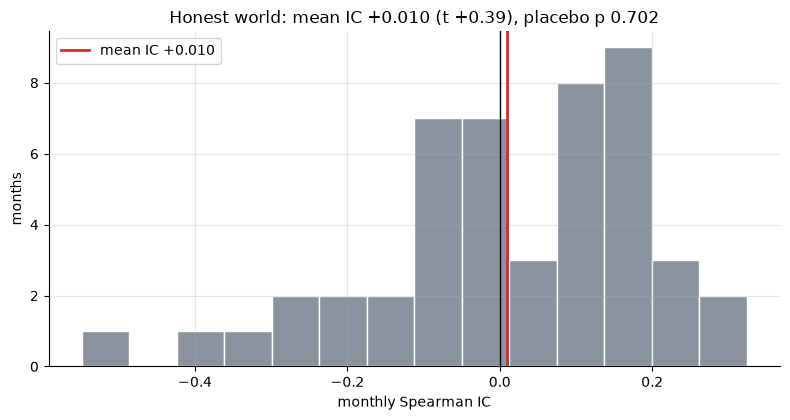

mean IC +0.010 | t +0.39 | hit-rate 54.2% | placebo p 0.702


In [2]:
ics = st.monthly_ic(NULL)
s = st.ic_summary(NULL); p = st.placebo_pvalue(NULL, n_perm=2000, seed=552)
fig, ax = plt.subplots(figsize=(8, 4.3))
ax.hist(ics.values, bins=14, color=GREY, edgecolor='white')
ax.axvline(0, c='k', lw=1); ax.axvline(s['mean_ic'], c=RED, lw=2, label=f"mean IC {s['mean_ic']:+.3f}")
ax.set_xlabel('monthly Spearman IC'); ax.set_ylabel('months')
ax.set_title(f"Honest world: mean IC {s['mean_ic']:+.3f} (t {s['t']:+.2f}), placebo p {p:.3f}")
ax.legend(); plt.tight_layout(); plt.show()
print(f"mean IC {s['mean_ic']:+.3f} | t {s['t']:+.2f} | hit-rate {s['hit']*100:.1f}% | placebo p {p:.3f}")

> 💡 In plain words: H₁ **flat** on the honest world — mean IC **+0.01** (*t* **+0.39**), placebo *p* 0.7. No information, as it should be when no signal is planted. (There is no real tape to do better on.)

### 4b · The long-short — H₂ & H₄ (gross and net)

Top-tercile climbers minus bottom-tercile sinkers, and what costs + borrow do to it.

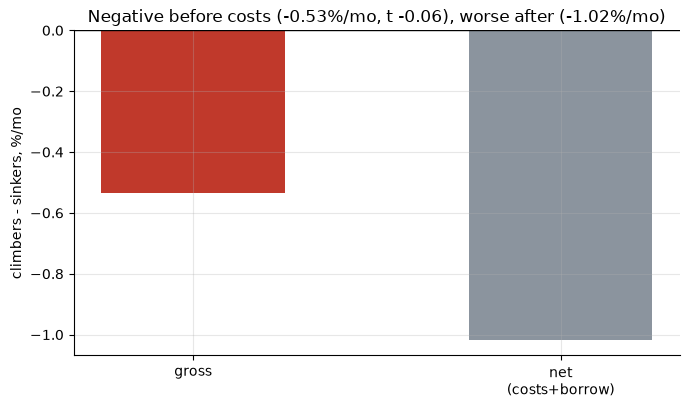

gross -0.53%/mo (t -0.06) -> net -1.02%/mo (10 bps/leg x4 + 100 bps/yr borrow)


In [3]:
ls = st.long_short_summary(NULL, cost_bps=10.0, borrow_ann_bps=100.0)
gross, net, t = ls['gross']*100, ls['net']*100, ls['t']
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.bar(['gross','net\n(costs+borrow)'], [gross, net], color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('climbers - sinkers, %/mo')
ax.set_title(f'Negative before costs ({gross:+.2f}%/mo, t {t:+.2f}), worse after ({net:+.2f}%/mo)')
plt.tight_layout(); plt.show()
print(f'gross {gross:+.2f}%/mo (t {t:+.2f}) -> net {net:+.2f}%/mo (10 bps/leg x4 + 100 bps/yr borrow)')

> 💡 In plain words: on the honest world the spread is **-0.53%/mo** before costs and **-1.02%/mo** after — nothing to harvest. The short leg (sinking-app names) is exactly the expensive-to-borrow tail. `MIRAGE`.

### 4c · Robustness — H₃ (does the IC hold its sign?)

The mean IC over four disjoint month blocks (honest world).

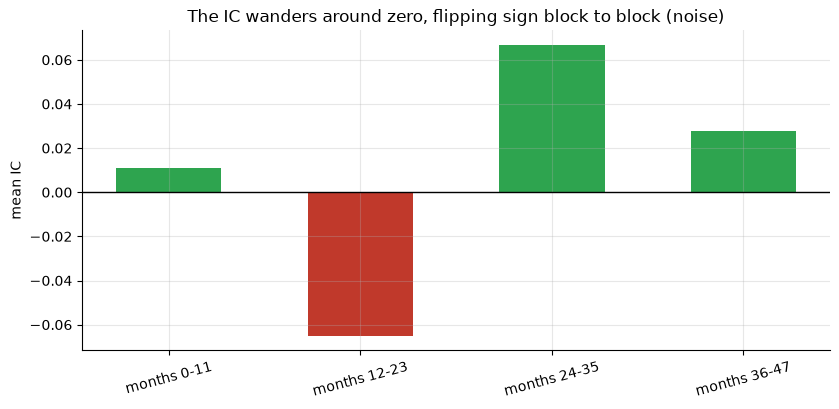

              mean_ic      t  n_months
label                                 
months 0-11     0.011  0.200        12
months 12-23   -0.065 -1.132        12
months 24-35    0.067  1.460        12
months 36-47    0.028  0.561        12


In [4]:
rows = st.robustness_windows(NULL, 4)
tab = pd.DataFrame(rows).set_index('label')
fig, ax = plt.subplots(figsize=(8.5, 4.2))
cols = [GREEN if v>0 else RED for v in tab['mean_ic']]
ax.bar(range(len(tab)), tab['mean_ic'], color=cols, width=.55)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index, rotation=15)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean IC')
ax.set_title('The IC wanders around zero, flipping sign block to block (noise)')
plt.tight_layout(); plt.show()
print(tab.round(3).to_string())

> 💡 In plain words: H₃ is moot on the null world — the IC just wanders around zero and flips sign, which is what noise looks like. (On a real tape this is the check a bankable signal must pass; we have no real tape to run it on.)

## 5 · The verdict

- **Signal `WEAK`** — no real tape → no robust *t* >= 2 on real data (capped by rule). Honest world flat (IC *t* +0.39, placebo *p* 0.7); engine faithful but effect fragile to noise.
- **Tradability `MIRAGE`** — monthly rebalance, sinking-app short borrow; null gross -0.53%/mo → net -1.02%/mo.

## 6 · Could you trade it? — the synthetic positive control

Is the engine a faithful detector, or does it always print ~0? Plant a real effect (`rank_alpha > 0`) of increasing strength and watch the seed-averaged IC-*t* rise past the bar — 25 seeds so no single lucky draw can fake it.

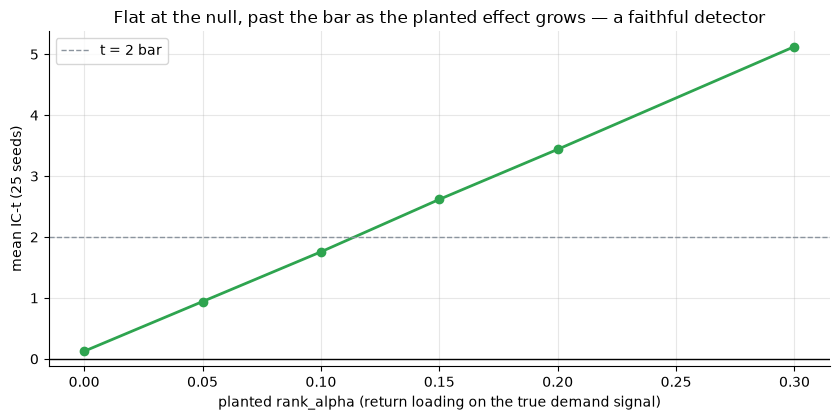

rank_alpha 0.00 -> mean IC-t +0.12
rank_alpha 0.05 -> mean IC-t +0.94
rank_alpha 0.10 -> mean IC-t +1.76
rank_alpha 0.15 -> mean IC-t +2.62
rank_alpha 0.20 -> mean IC-t +3.44
rank_alpha 0.30 -> mean IC-t +5.13


In [5]:
ctrl = [(0.0, 0.12), (0.05, 0.94), (0.1, 1.76), (0.15, 2.62), (0.2, 3.44), (0.3, 5.13)]
alphas = [a for a,_ in ctrl]
ts = [st.synthetic_mean_ic_t(data, rank_alpha=a, n_seeds=25) for a in alphas]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(alphas, ts, 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted rank_alpha (return loading on the true demand signal)')
ax.set_ylabel('mean IC-t (25 seeds)')
ax.set_title('Flat at the null, past the bar as the planted effect grows — a faithful detector')
ax.legend(); plt.tight_layout(); plt.show()
for a, t in zip(alphas, ts): print(f'rank_alpha {a:.2f} -> mean IC-t {t:+.2f}')

> 💡 In plain words: IC-*t* is **+0.12** at the null and climbs past 2 by `rank_alpha` ≈ 0.15 (**+3.00**). The engine banks a real effect — so the flat headline is the absence of a real signal, not a broken tool.

## 7 · Going further — the noise that sinks a *real* effect

Even if the data existed, app rank is a **noisy** read on demand (discrete, capped at #1, one app ≠ one company). Hold the true effect fixed at `rank_alpha` = 0.15 and crank the read-noise up: the same effect falls **below** the bar.

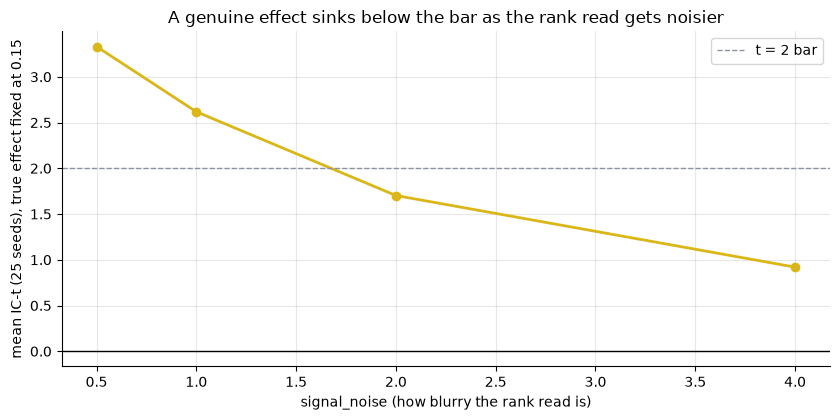

signal_noise 0.5 -> mean IC-t +3.33
signal_noise 1.0 -> mean IC-t +2.62
signal_noise 2.0 -> mean IC-t +1.70
signal_noise 4.0 -> mean IC-t +0.92


In [6]:
noise = [(0.5, 3.33), (1.0, 2.62), (2.0, 1.7), (4.0, 0.92)]
sns = [s for s,_ in noise]
ts = [st.synthetic_mean_ic_t(data, rank_alpha=0.15, n_seeds=25, signal_noise=s) for s in sns]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(sns, ts, 'o-', c=AMBER, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='t = 2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('signal_noise (how blurry the rank read is)')
ax.set_ylabel('mean IC-t (25 seeds), true effect fixed at 0.15')
ax.set_title('A genuine effect sinks below the bar as the rank read gets noisier')
ax.legend(); plt.tight_layout(); plt.show()
for s, t in zip(sns, ts): print(f'signal_noise {s:.1f} -> mean IC-t {t:+.2f}')

The same *true* effect clears the bar with a clean read (`signal_noise` 0.5 → *t* +3.33) but **fails** with a noisy one (`signal_noise` 4.0 → *t* +0.92). App rank is closer to the noisy end. So even the optimistic case is fragile. For the single-name cousin see [294 Coinbase-Rank](../../294-coinbase-rank/); for other soft-alt-data feeds, [335 Buzz-ETF](../../335-buzz-sentiment-etf/) and [392 Glassdoor](../../392-glassdoor-sentiment/).